In [30]:
import matplotlib.pyplot as plt
import pandas as pd


In [31]:
# function to find spikes in the loss
def find_spikes(loss, threshold=0.1):
    spikes = []
    for i in range(1, len(loss) - 1):
        if loss[i] > loss[i - 1] * (1 + threshold) and loss[i] > loss[i + 1] * (1 + threshold):
            spikes.append(i)
    return spikes

Spikes found at epochs: [35, 54, 74]


Text(0, 0.5, 'Loss')

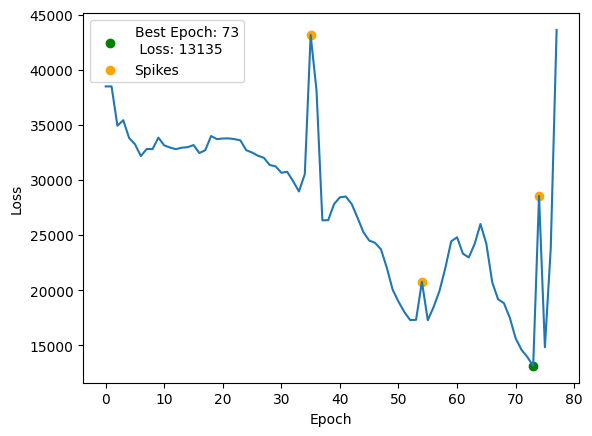

In [32]:
# import data
optimisation_log = pd.read_csv("optimisation_log.csv")
optimisation_log

epoch = optimisation_log["epoch"].values
loss = optimisation_log["loss"].values

lowest_loss = min(loss)
best_epoch = epoch[loss.argmin()]

spikes = find_spikes(loss, threshold=0.1)
print(f"Spikes found at epochs: {spikes}")

plt.plot(epoch, loss)
plt.scatter(best_epoch, lowest_loss, color="green", label=f"Best Epoch: {best_epoch}\n Loss: {lowest_loss:.0f}")
plt.scatter(epoch[spikes], loss[spikes], color="orange", label="Spikes")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")


We want to investigate which change in parameters causes the spikes in loss

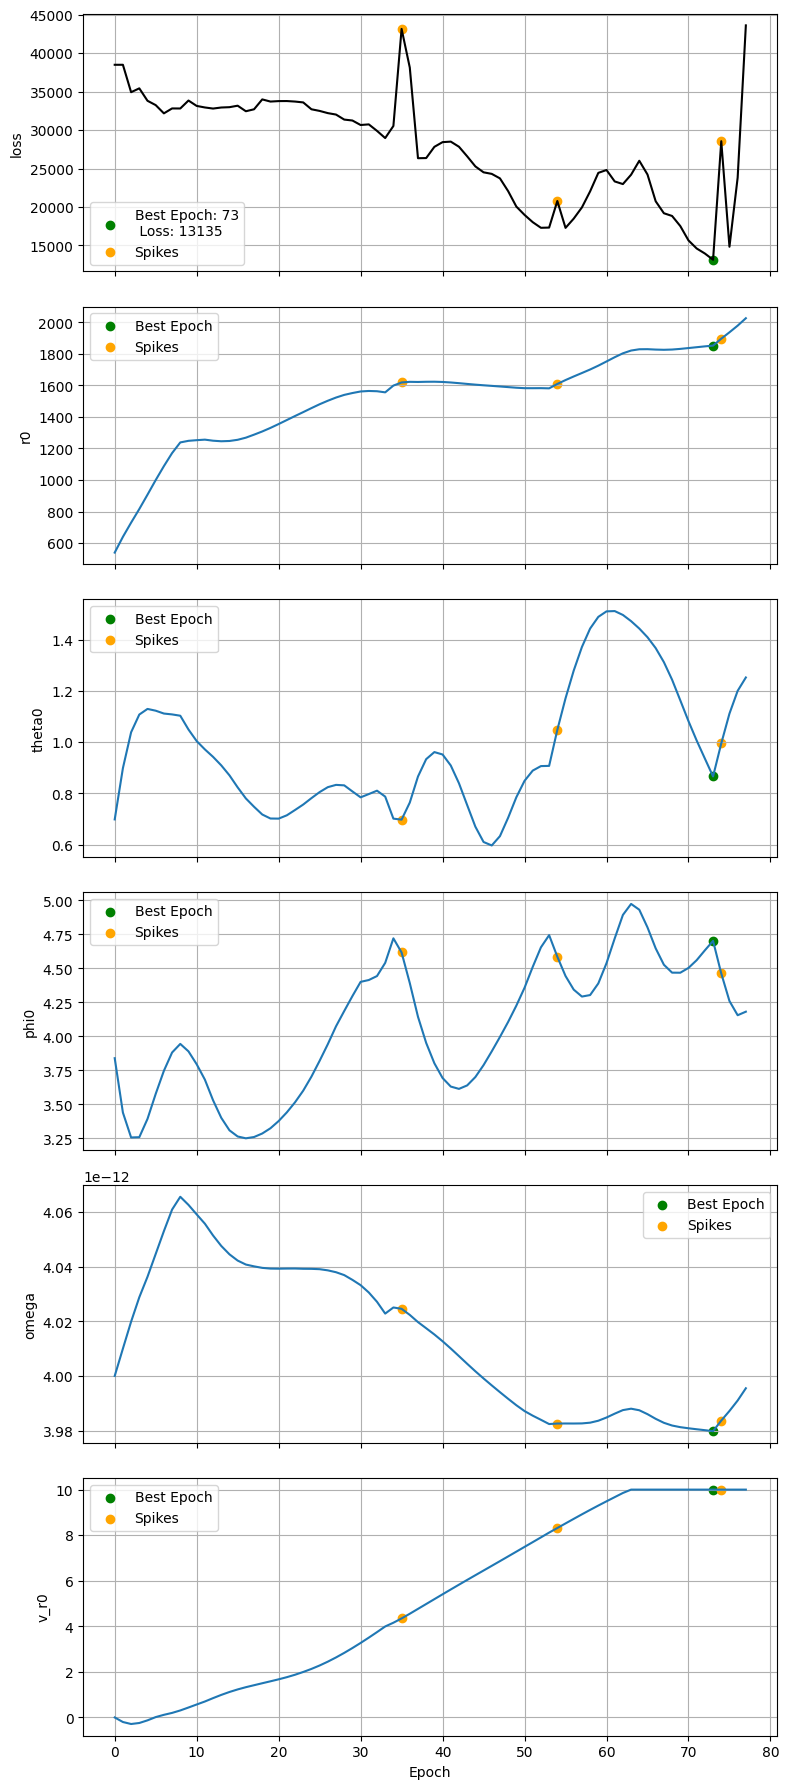

In [35]:
# plot the parameters over epochs in a single figure with subplots
param_names = [col for col in optimisation_log.columns if col not in ("epoch", "loss")]

fig, axes = plt.subplots(len(param_names) + 1, 1, figsize=(8, 3 * (len(param_names) + 1)), sharex=True)
loss_ax = axes[0]
loss_ax.plot(epoch, loss, color="black")
loss_ax.scatter(best_epoch, lowest_loss, color="green", label=f"Best Epoch: {best_epoch}\n Loss: {lowest_loss:.0f}")
loss_ax.scatter(epoch[spikes], loss[spikes], color="orange", label="Spikes")
loss_ax.set_ylabel("loss")
loss_ax.grid(True)
loss_ax.legend()

for ax, param in zip(axes[1:], param_names):
    param_values = optimisation_log[param].values
    ax.plot(epoch, param_values)
    ax.scatter(best_epoch, param_values[loss.argmin()], color="green", label="Best Epoch")
    ax.scatter(epoch[spikes], param_values[spikes], color="orange", label="Spikes")
    ax.set_ylabel(param)
    ax.grid(True)
    ax.legend()

axes[-1].set_xlabel("Epoch")
fig.tight_layout()
plt.show()